# Adaptive tau leap investigations

In this notebook we examine the behaviour of Cao's adaptive tau leap algorithm when applied to an SIR model.

First, set up the model with pygom:

In [55]:
import numpy as np

from pygom import Event, Transition, SimulateOde
import matplotlib.pyplot as plt

from pygom.stochastic_solving.src.stochastic_sim.config import TauConfig, Cao2006TauConfig

from pygom.stochastic_solving.src.stochastic_sim.api import solve
N = 1e5
R0 = 1.5
gamma = 1/4.0
beta = R0 * gamma

# Params and states
params=['beta', 'gamma', 'N']
states=['S', 'I', 'R']

# State Limits (stochastic solver needs to know variable limits to assess illegal steps)
xlims = np.asarray([(0, N), (0, N), (0, N)], dtype=object)
mins = np.array([lim[0] if lim[0] is not None else -np.inf for lim in xlims])
maxs = np.array([lim[1] if lim[1] is not None else np.inf for lim in xlims])

# Transitions
transition_infection=Transition(origin='S', destination='I', transition_type='T', magnitude='1')
event_infection=Event(transition_list=[transition_infection], rate='beta*S*I/N')

transition_recovery=Transition(origin='I', destination='R', transition_type='T', magnitude='1')
event_recovery=Event(transition_list=[transition_recovery], rate='gamma*I')

model=SimulateOde(state=states, param=params, event=[event_infection, event_recovery])
model.parameters = {"beta": beta, "gamma": gamma, "N":N}

# Functions to input to solvers
transition_func = model.event_rate_vector           # rates at which events occur
state_change_mat = model.state_change_matrix        # state change as a result of each event
transition_mean_func = model.transition_mean        # (for adaptive tau) mean change of rates
transition_var_func = model.transition_variance     # (for adaptive tau) variance of change

Then simulate some epidemics with different values of epsilon

In [56]:
# Initial conditions
i0 = 1
x0 = np.array([N-i0, i0, 0])

def get_dt(epsilon):
    print(f"Epsilon: {epsilon}")

    algo =  TauConfig(method=Cao2006TauConfig(epsilon=epsilon))

    # Keep simulating until we get a successful epidemic
    final_size = 0
    while final_size < 100:
        sim = solve(
            x0=x0,
            t_max=10000,                                    # set some large value so that max time doesn't cut simulation short (proceed_if_rates_zero must be False)
            ode_eqns=transition_func,
            state_change_mat=state_change_mat,
            x_min=mins, x_max=maxs,
            config=algo,                                    # stepper method (tau fixed / tau adaptive / exact direct / exact first etc....) plus relevant params
            perf=True,                                      # output performance diagnostics
            proceed_if_rates_zero=False,                    # stop the simulation when all rates = 0 (epidemic has ended)
            transition_mean_func=transition_mean_func,
            transition_var_func=transition_var_func
        )

        final_size = sim.out.x[-1,2]

    inf = sim.out.x[:, 1]
    t = sim.out.t
    dt = np.diff(t)

    return inf, t, dt

epsilons = [0.01, 0.03, 0.1, 0.3]

infs = []
ts = []
dts = []

for epsilon in epsilons:
    inf, t, dt = get_dt(epsilon)
    infs.append(inf)
    ts.append(t)
    dts.append(dt)

Epsilon: 0.01
Epsilon: 0.03
Epsilon: 0.1
Epsilon: 0.3


We see how epsilon changes the nature of the timesteps:

1) Smallest timesteps usually around onset of exponential growth
2) Largest timesteps around peak and early/late stages (gradients tending to zero)
3) Importantly, the initial timestep cannot be made arbitrarily small by reducing epsilon. This means that it might be difficult to estimate properties such as extinction probability using the Cao method.

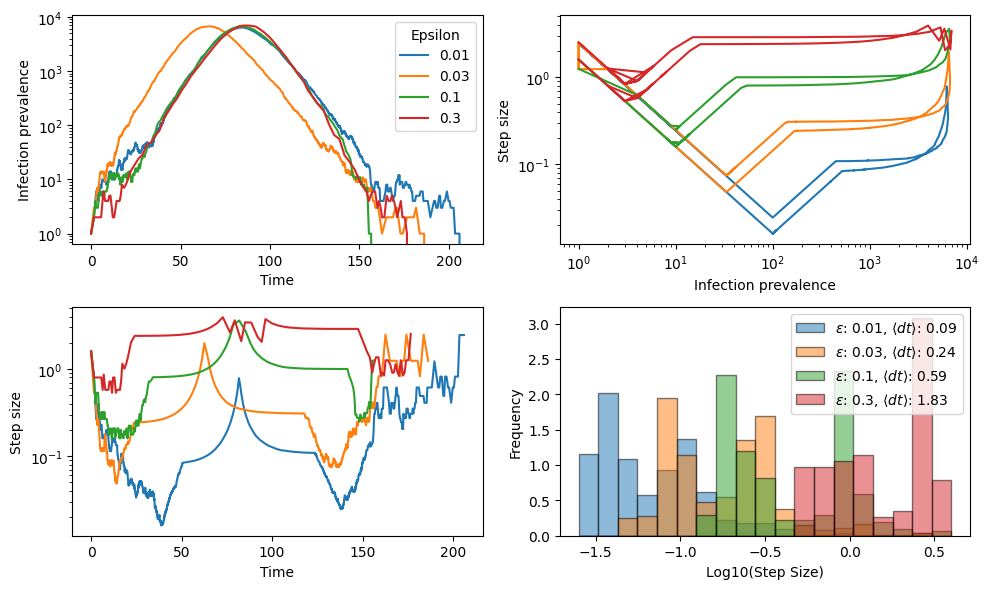

In [57]:
N = len(epsilons)

fig, ax = plt.subplots(2, 2, figsize = (10,6))

for i in range(N):
    ax[0][0].plot(ts[i], infs[i], label=epsilons[i])
ax[0][0].set_yscale("log")
ax[0][0].set_xlabel("Time")
ax[0][0].set_ylabel("Infection prevalence")
ax[0][0].legend(title="Epsilon")

for i in range(N):
    ax[1][0].plot(ts[i][:-1], dts[i], label=epsilons[i])
ax[1][0].set_yscale("log")
ax[1][0].set_xlabel("Time")
ax[1][0].set_ylabel("Step size")

for i in range(N):
    ax[0][1].plot(infs[i][:-1], dts[i], label=epsilons[i])
ax[0][1].set_xscale("log")
ax[0][1].set_yscale("log")
ax[0][1].set_xlabel("Infection prevalence")
ax[0][1].set_ylabel("Step size")

for i in range(N):
    dt = dts[i]
    dt = dt[dt > 0]
    mn = dt.mean()
    bins = np.linspace(-1.6, 0.6, 20)
    dt = np.log10(dt)
    ax[1][1].hist(dt, bins=bins, density=True, alpha=0.5, label=f"$\\epsilon$: {epsilons[i]}, $\\langle dt \\rangle$: {mn:.2f}", edgecolor="black")
ax[1][1].set_xlabel("Log10(Step Size)")
ax[1][1].legend()
ax[1][1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Now we focus in on the initial timesteps to see how this is unchanged by epsilon.

It can, in fact, be shown that the initial timestep for small epsilon is: $\frac{1}{\beta + \gamma}$ (i.e. independent of $\epsilon$)

This is why (under Cao formalism) we cannot keep reducing epsilon to improve extinction probability estimates.

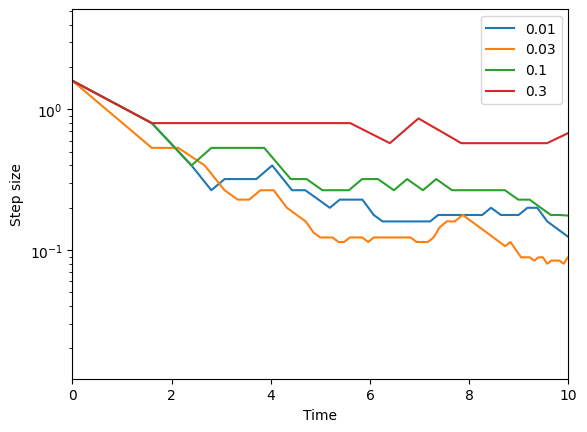

In [58]:
for i in range(N):
    plt.plot(ts[i][:-1], dts[i], label=epsilons[i])
plt.xlim(0, 10)
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Step size")
plt.legend()
plt.show()